In [4]:
"""
S&P 500 Stock Price Forecasting Pipeline
Includes: Feature Engineering, ARIMA, SARIMA, Prophet, XGBoost, LightGBM
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from ta import add_all_ta_features # Automated financial feature generator

# Optional: yfinance just to download dummy AAPL data if you want to test this immediately
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')
# import pmdarima as pm

# ML models
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb


# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
!pip install ta yfinance

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=292529ab7dcf4e45629c6d64a0ca7f7ca78d23276696a26f0175552713b038a7
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [3]:
df = pd.read_parquet('/content/cleaned_s&p500.parquet')

stock = 'AAPL'
aapl_df = df[df['Name'] == stock].copy()

aapl_df['date'] = pd.to_datetime(aapl_df['date'])
aapl_df = aapl_df.sort_values('date')
aapl_df.set_index('date', inplace=True)

print(aapl_df.head())
print(aapl_df.shape)

               open     high      low    close     volume  Name
date                                                           
2013-02-08  67.7142  68.4014  66.8928  67.8542  158168416  AAPL
2013-02-11  68.0714  69.2771  67.6071  68.5614  129029425  AAPL
2013-02-12  68.5014  68.9114  66.8205  66.8428  151829363  AAPL
2013-02-13  66.7442  67.6628  66.1742  66.7156  118721995  AAPL
2013-02-14  66.3599  67.3771  66.2885  66.6556   88809154  AAPL
(1259, 6)


In [7]:
print("Generating features...")

# 1. Generate Technical Indicators using the 'ta' library

aapl_df = add_all_ta_features(
    aapl_df, open="open", high="high", low="low", close="close", volume="volume", fillna=True
)

# 2. Generate Calendar Features
aapl_df['DayOfWeek'] = aapl_df.index.dayofweek
aapl_df['Month'] = aapl_df.index.month
aapl_df['Quarter'] = aapl_df.index.quarter

# 3. Generate Lag Features (Previous days' closing prices)
# This tells the model what the price was 1, 2, and 3 days ago.
for i in range(1, 4):
    aapl_df[f'Close_Lag_{i}'] = aapl_df['close'].shift(i)

# 4. Define the Target Variable
aapl_df['Target_Next_Close'] = aapl_df['close'].shift(-1)

# Drop NaN values created by shifting and rolling windows
aapl_df.dropna(inplace=True)

print(f"New dataset shape with features: {aapl_df.shape}")

Generating features...
New dataset shape with features: (1255, 99)


In [10]:
# This automatically drops 'Name', 'Ticker', or any other text columns
# while keeping all your numeric data and technical features intact.
aapl_df = aapl_df.select_dtypes(exclude=['object'])

# Optional: Double-check your data types to ensure no 'object' dtypes remain
print(aapl_df.dtypes)

open                 float64
high                 float64
low                  float64
close                float64
volume                 int64
                      ...   
Quarter                int32
Close_Lag_1          float64
Close_Lag_2          float64
Close_Lag_3          float64
Target_Next_Close    float64
Length: 98, dtype: object


In [11]:
# We will use the last 20% of the data for testing
split_idx = int(len(aapl_df) * 0.8)

train_data = aapl_df.iloc[:split_idx]
test_data = aapl_df.iloc[split_idx:]

# Separate features (X) and target (y)
features = [col for col in aapl_df.columns if col != 'Target_Next_Close']

X_train = train_data[features]
y_train = train_data['Target_Next_Close']

X_test = test_data[features]
y_test = test_data['Target_Next_Close']

print(f"Training records: {len(X_train)} | Testing records: {len(X_test)}")

Training records: 1004 | Testing records: 251


In [12]:
# Initialize and train the XGBoost Regressor
# We use relatively conservative hyperparameters to prevent overfitting
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

print("Training XGBoost model...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False # Set to True to see training logs
)
print("Training complete!")

Training XGBoost model...
Training complete!


Mean Absolute Error (MAE): $27.55
Root Mean Squared Error (RMSE): $30.37


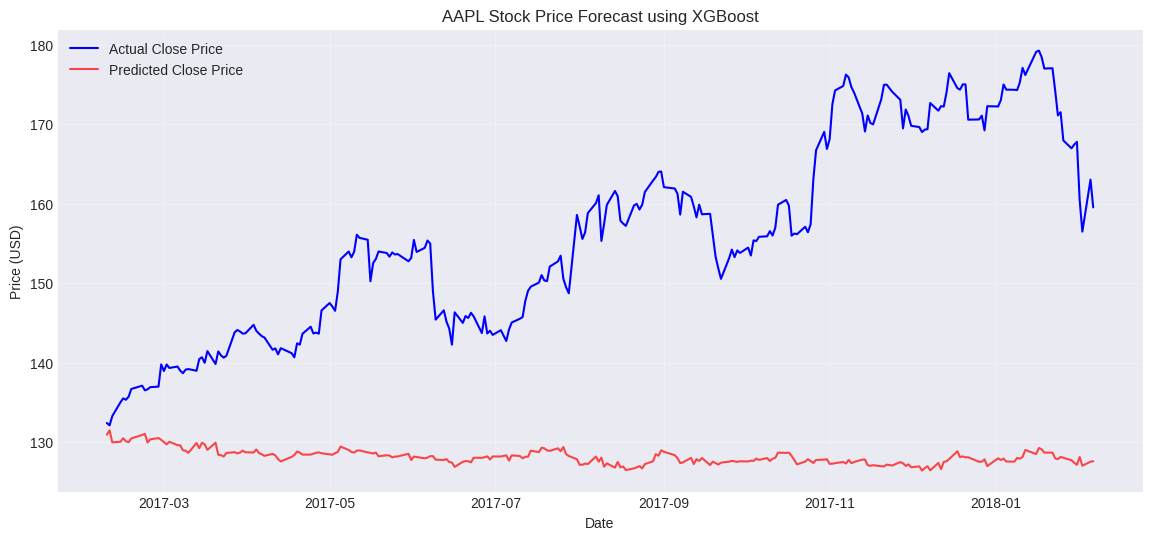

In [13]:
# Make predictions on the test set
predictions = xgb_model.predict(X_test)

# Calculate error metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

# Plotting the results
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label='Actual Close Price', color='blue')
plt.plot(y_test.index, predictions, label='Predicted Close Price', color='red', alpha=0.7)
plt.title('AAPL Stock Price Forecast using XGBoost')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

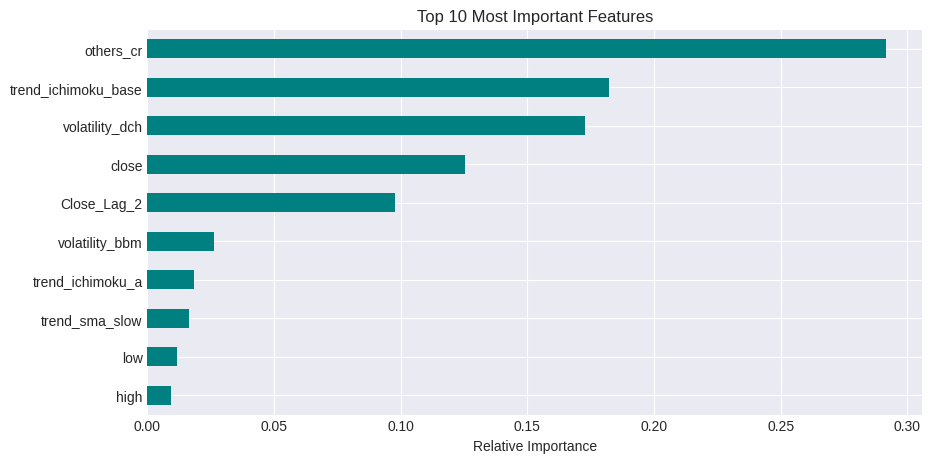

In [14]:
# Plot the top 10 most important features
feature_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
feature_importances.nlargest(10).sort_values().plot(kind='barh', figsize=(10, 5), color='teal')
plt.title('Top 10 Most Important Features')
plt.xlabel('Relative Importance')
plt.show()

In [16]:
# ==========================================
# 1. THE FIX: Predict % Returns, not Prices
# ==========================================
# Target is now tomorrow's percentage return
aapl_df['Target_Next_Return'] = aapl_df['close'].pct_change().shift(-1)

# Drop NaNs
aapl_df.dropna(inplace=True)


In [17]:
# ==========================================
# 2. Train / Test Split
# ==========================================
split_idx = int(len(aapl_df) * 0.8)
train_data = aapl_df.iloc[:split_idx]
test_data = aapl_df.iloc[split_idx:]

# Ensure we don't accidentally leak the target price or target return into features
features = [col for col in aapl_df.columns if col not in ['Target_Next_Close', 'Target_Next_Return']]

X_train = train_data[features]
y_train = train_data['Target_Next_Return'] # Training on RETURNS now

X_test = test_data[features]
y_test = test_data['Target_Next_Return']


In [18]:
# ==========================================
# 3. Train Model
# ==========================================
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

print("Training XGBoost on daily returns...")
xgb_model.fit(X_train, y_train)


Training XGBoost on daily returns...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [20]:
# ==========================================
# 4. Predict & Convert Back to Prices
# ==========================================
# Predict tomorrow's return
predicted_returns = xgb_model.predict(X_test)

# Math: Predicted Price Tomorrow = Actual Price Today * (1 + Predicted Return)
predicted_prices = test_data['close'].values * (1 + predicted_returns)

# Get the actual prices for tomorrow to compare against
actual_prices = test_data['close'].shift(-1).values

# Trim the last row since we don't have an "actual price" for the day after the dataset ends
predicted_prices = predicted_prices[:-1]
actual_prices = actual_prices[:-1]
plot_dates = test_data.index[:-1]
#

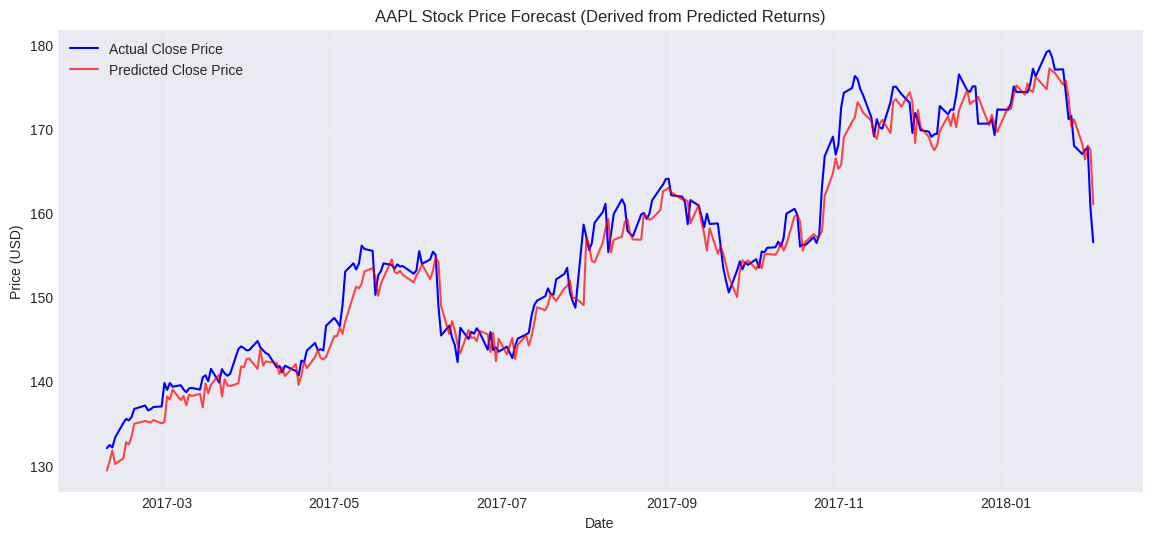

In [21]:
# ==========================================
# 5. Plot the New Reality
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(plot_dates, actual_prices, label='Actual Close Price', color='blue')
plt.plot(plot_dates, predicted_prices, label='Predicted Close Price', color='red', alpha=0.7)
plt.title('AAPL Stock Price Forecast (Derived from Predicted Returns)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
